<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 50%, #0a0a1a 100%); padding: 40px 32px 32px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-bottom: 8px;">

<div style="display: flex; align-items: flex-start; gap: 24px;">
<div style="flex: 1;">

<p style="color: #7eb8e0; font-family: 'Courier New', monospace; font-size: 20px; letter-spacing: 3px; margin: 0 0 10px 0; text-transform: uppercase;">Cosmic Explosion Exploration - LIGO Gravitational Wave Analysis Pipeline</p>

<h1 style="color: #e8f4fd; font-size: 2.2em; margin: 0 0 6px 0; font-weight: 300; letter-spacing: 1px;">Notebook 01 — Data Acquisition</h1>

<p style="color: #a0c4de; font-size: 1.05em; margin: 0 0 20px 0; font-style: italic;">Fetching gravitational wave strain from the LIGO Open Science Center</p>

<div style="display: flex; gap: 24px; flex-wrap: wrap;">
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Default event</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">GW150914</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">14 September 2015 · Binary Black Hole</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Detectors</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">H1 · L1</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">Hanford (WA) · Livingston (LA)</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Pipeline stage</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">01 of 06</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">Outputs raw HDF5 → passed to 02</p>
  </div>
</div>

</div>
</div>

<hr style="border: none; border-top: 1px solid rgba(126,184,224,0.2); margin: 24px 0 16px 0;">

<p style="color: #7eb8e0; font-size: 12px; font-family: 'Courier New', monospace; margin: 0;">
  <span style="opacity:0.6;">Pipeline:</span> &nbsp;
  
</p>

</div>

In [1]:
from pipeline_banner import pipeline_banner
pipeline_banner(1)   # ← change the number per notebook

## The Event: GW150914

![An aerial view of the Virgo site](https://news.mit.edu/sites/default/files/styles/news_article__image_gallery/public/images/201709/MIT-LIGO-Virgo-1_0.jpg?itok=xvGmRILC)

On **14 September 2015 at 09:50:45 UTC**, two laser interferometers on opposite sides of the United States simultaneously registered a tiny shudder that lasted less than a second. Buried in the detector noise was a signal that had been travelling for **1.3 billion years** — the dying shriek of two black holes tearing into each other and merging into a single object.

The event, named **GW150914** (Gravitational Wave, year 2015, month 09, day 14), confirmed the last great untested prediction of Einstein's General Relativity and opened an entirely new branch of observational astronomy.

### What actually happened?

The two black holes — approximately **36 and 29 times the mass of the Sun** — had been locked in a mutual orbit for billions of years, spiralling imperceptibly closer as they radiated energy. In their final moments, the inspiral accelerated dramatically. In the last **0.2 seconds** they swept from ~35 Hz to ~150 Hz (the chirp), then merged into a single **62 M☉** remnant. The missing 3 M☉ was converted to pure energy in the form of gravitational waves — briefly releasing more power than **all visible stars in the observable universe combined**.

So what are gravitational waves? Think of them as ripples in the fabric of space and time, similar to the ripples that spread across a pond when you throw a stone into it. These ripples are caused by massive objects moving or colliding in space.

### How small was the signal?

By the time those waves arrived at Earth, the strain amplitude was on the order of **h ≈ 1 × 10⁻²¹**. The strain h(t) is defined as:

$$h(t) = \frac{\Delta L(t)}{L}$$

where $L$ is the arm length of the interferometer and $\Delta L(t)$ is the change in that length caused by the passing wave. LIGO's arms are **4 km** long. A strain of 10⁻²¹ corresponds to a length change of:

$$\Delta L = h \times L = 10^{-21} \times 4{,}000\text{ m} = 4 \times 10^{-18}\text{ m}$$

That is roughly **one-thousandth the diameter of a proton**. Measuring this is perhaps the most precise measurement ever made by human beings.

### How LIGO works (briefly)

Each LIGO detector is a [**Michelson interferometer**](https://en.wikipedia.org/wiki/Michelson_interferometer)
 at its core. A laser beam is split and sent down two perpendicular 4-km arms. When a gravitational wave passes, it stretches space in one direction and squeezes it in the perpendicular direction — causing the two arms to change length by different amounts. The returning beams no longer cancel perfectly, and a tiny fluctuation in light intensity reveals the strain.

The challenge is that the detector is exquisitely sensitive to *everything* — ground vibrations, thermal fluctuations in mirror coatings, quantum fluctuations in the laser light. Separating the gravitational wave signal from all of these noise sources is what we will explore subsequent notebooks 02–05.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 0 — Environment Setup</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Install and verify required packages. The <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">%%capture</code> magic suppresses verbose pip output — remove it if you need to debug an install.</p>
</div>

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np

# Try importing matplotlib with error handling
try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import matplotlib
    matplotlib_available = True # This flag was added as a check due to some environment issues found during project!
    print("✓ Matplotlib imported successfully")
except ImportError as e:
    print(f"⚠️  Matplotlib import failed: {e}")
    print("   Try: pip install --upgrade matplotlib")
    print("   Or: conda install matplotlib --force-reinstall")
    matplotlib_available = False

import h5py

# ── LIGO-specific ─────────────────────────────────────────────────────────────
try:
    from gwpy.timeseries import TimeSeries
    from gwpy.time import to_gps
    import gwpy, astropy
    gwpy_available = True
    print("✓ GWpy imported successfully")
except ImportError as e:
    print(f"⚠️  GWpy import failed: {e}")
    print("   Try: pip install gwpy")
    gwpy_available = False

# ── Pipeline modules ──────────────────────────────────────────────────────────
sys.path.insert(0, ".")
try:
    from config import PATHS, EVENT, SIGNAL, VIZ
    from utils import time_relative_to_merger, print_hdf5_tree
    config_available = True
    print("✓ Local modules imported successfully")
except ImportError as e:
    print(f"⚠️  Local module import failed: {e}")
    print("   Check if config.py and utils.py exist in current directory")
    config_available = False

# ── Version check ─────────────────────────────────────────────────────────────
print(f"\n{'Library':<12} {'Version'}")
print("-" * 24)

# Always available libraries
print(f"{'numpy':<12} {np.__version__}")
print(f"{'h5py':<12} {h5py.__version__}")

# Conditionally check versions for libraries that imported successfully
if matplotlib_available:
    print(f"{'matplotlib':<12} {matplotlib.__version__}")
if gwpy_available:
    print(f"{'gwpy':<12} {gwpy.__version__}")
    print(f"{'astropy':<12} {astropy.__version__}")

print("\n" + ("✓ Environment ready." if matplotlib_available and gwpy_available and config_available 
              else "⚠️  Some imports failed - check error messages above."))

✓ Matplotlib imported successfully
✓ GWpy imported successfully
✓ Local modules imported successfully

Library      Version
------------------------
numpy        2.4.6
h5py         3.16.0
matplotlib   3.10.9
gwpy         4.0.1
astropy      7.2.0

✓ Environment ready.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 1 — Matplotlib Theme</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Apply a deep-space dark theme with a more visually compelling colour palette. This is set once and inherited by all plots in this notebook.</p>
</div>

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEEP-SPACE MATPLOTLIB THEME
# Instead of pure black, the colour palette was adjusted to use the same colouring used in
# real LIGO publication figures for a clean, observatory themed  aesthetic.
# ═══════════════════════════════════════════════════════════════════════════════

SPACE_BG     = "#0d1117"    # Near-black background (GitHub dark-mode inspired)
SPACE_AXES   = "#131c27"    # Slightly lighter for axes faces
SPACE_GRID   = "#1e2d3e"    # Subtle grid lines
SPACE_TEXT   = "#c9d9e8"    # Pale blue-white text
SPACE_BORDER = "#2a4a6e"    # Axis spine colour

# ── Detector palette ─────────────────────────────────────────────
WA_COLOURS = {
    "H1": "#E07B54",   # Warm coral-orange
    "L1": "#5AAFA0",   # Dusty teal-green
    "V1": "#D4A84B",   # Warm golden sand
    "merger": "#F2C46D",  # Butter-yellow for the merger marker
    "bandpass": "#8BBF9F", # Sage for frequency band shading
}

plt.rcParams.update({
    # Background
    "figure.facecolor":   SPACE_BG,
    "axes.facecolor":     SPACE_AXES,
    "savefig.facecolor":  SPACE_BG,

    # Text
    "text.color":         SPACE_TEXT,
    "axes.labelcolor":    SPACE_TEXT,
    "xtick.color":        SPACE_TEXT,
    "ytick.color":        SPACE_TEXT,

    # Spines and grid
    "axes.edgecolor":     SPACE_BORDER,
    "grid.color":         SPACE_GRID,
    "grid.linewidth":     0.6,
    "axes.grid":          True,
    "axes.grid.which":    "both",

    # Font sizes
    "axes.titlesize":     12,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "figure.titlesize":   14,

    # Lines
    "lines.linewidth":    0.9,
    "axes.linewidth":     0.8,

    # Layout
    "figure.constrained_layout.use": True,
})

print("Theme applied — deep-space dark")
print(f"  H1 (Hanford)    → {WA_COLOURS['H1']}  (warm coral)")
print(f"  L1 (Livingston) → {WA_COLOURS['L1']}  (dusty teal)")
print(f"  V1 (Virgo)      → {WA_COLOURS['V1']}  (golden sand)")

Theme applied — deep-space dark
  H1 (Hanford)    → #E07B54  (warm coral)
  L1 (Livingston) → #5AAFA0  (dusty teal)
  V1 (Virgo)      → #D4A84B  (golden sand)


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 2 — Event Selector</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">To analyse a different event, edit only the <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">ACTIVE_EVENT</code> variable below and re-run all cells. Everything else — paths, filenames, plot titles — updates automatically.</p>
</div>

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# EVENT SELECTOR
# ───────────────────────────────────────────────────────────────────────────────
# This selector section is added to allow to, change ACTIVE_EVENT to any key from EVENT_CATALOGUE below.
# All downstream cells use the selected event's parameters automatically.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Catalogue of notable gravitational wave events ────────────────────────────
# Each entry: GPS merger time, source type, detectors, and a brief note.
#
# BBH  = Binary Black Hole
# BNS  = Binary Neutron Star
# NSBH = Neutron Star – Black Hole

EVENT_CATALOGUE = {
    "GW150914": {
        "gps": 1126259462, "type": "BBH",  "detectors": ["H1", "L1"],
        "masses": "36 + 29 M☉", "distance_Mpc": 410,
        "note": "First ever direct detection. Two stellar-mass black holes, ~1.3 Gly away.",
    },
    "GW170814": {
        "gps": 1186741861, "type": "BBH",  "detectors": ["H1", "L1", "V1"],
        "masses": "30.5 + 25.3 M☉", "distance_Mpc": 540,
        "note": "First triple-detector observation; allowed sky localisation to ~60 deg².",
    },
    "GW170817": {
        "gps": 1187008882, "type": "BNS",  "detectors": ["H1", "L1", "V1"],
        "masses": "1.36 + 1.17 M☉", "distance_Mpc": 40,
        "note": "Binary neutron star — with optical/radio/X-ray counterpart (kilonova). Dawn of multi-messenger astronomy.",
    },
    "GW190521": {
        "gps": 1242442967, "type": "BBH",  "detectors": ["H1", "L1", "V1"],
        "masses": "95 + 69 M☉",  "distance_Mpc": 5300,
        "note": "Heaviest BBH detected at the time; remnant exceeds the pair-instability mass gap.",
    },
    "GW200105": {
        "gps": 1262276512, "type": "NSBH", "detectors": ["H1", "L1", "V1"],
        "masses": "8.9 + 1.9 M☉",  "distance_Mpc": 280,
        "note": "Neutron star–black hole merger; the lighter component is consistent with a NS.",
    },
}

##### =========  CHANGE THIS TO SWITCH EVENTS ===================================
ACTIVE_EVENT = "GW150914"
##### ===========================================================================

assert ACTIVE_EVENT in EVENT_CATALOGUE, (
    f"Unknown event '{ACTIVE_EVENT}'. "
    f"Valid choices: {list(EVENT_CATALOGUE.keys())}"
)

ev = EVENT_CATALOGUE[ACTIVE_EVENT]

# Unpack into working variables used throughout the notebook
EVENT_NAME       = ACTIVE_EVENT
GPS_MERGE_TIME   = ev["gps"]
DETECTORS        = ev["detectors"]
SEGMENT_DURATION = 32                  # seconds of data centred on merger
GPS_START        = GPS_MERGE_TIME - SEGMENT_DURATION // 2
GPS_END          = GPS_MERGE_TIME + SEGMENT_DURATION // 2

# Ensure output directory exists
PATHS.make_dirs()
RAW_DATA_DIR = PATHS.RAW_DIR

# Pretty summary
print("══════════════════════════════════════════")
print(f"  Active event  : {EVENT_NAME}")
print(f"  Type          : {ev['type']}")
print(f"  Component masses : {ev['masses']}")
print(f"  Distance      : {ev['distance_Mpc']} Mpc")
print(f"  GPS merger    : {GPS_MERGE_TIME}")
print(f"  Fetch window  : [{GPS_START}, {GPS_END}]  ({SEGMENT_DURATION} s)")
print(f"  Detectors     : {DETECTORS}")
print(f"  Output dir    : {RAW_DATA_DIR.resolve()}")
print("══════════════════════════════════════════")
print(f"  {ev['note']}")

══════════════════════════════════════════
  Active event  : GW150914
  Type          : BBH
  Component masses : 36 + 29 M☉
  Distance      : 410 Mpc
  GPS merger    : 1126259462
  Fetch window  : [1126259446, 1126259478]  (32 s)
  Detectors     : ['H1', 'L1']
  Output dir    : C:\Users\paddy\Jupyter_Notebooks\LIGO Exploration\data\raw
══════════════════════════════════════════
  First ever direct detection. Two stellar-mass black holes, ~1.3 Gly away.


## GPS Time: The LIGO Clock

LIGO timestamps everything in **GPS time** — the number of seconds elapsed since **6 January 1980 at 00:00:00 UTC**. Unlike Unix time, GPS time does *not* insert leap seconds, so it diverges from UTC by a growing integer offset (currently 18 seconds). All LIGO data files, GWOSC URLs, and event catalog entries use the same GPS epoch (the starting point for GPS time).

GW150914 occurred at GPS **1,126,259,462** — that is over 1.1 billion seconds after midnight on 6 January 1980. The 32-second data segment centred on that time, GPS [1126259446 → 1126259478], is the window we fetch below.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 3 — Fetch Strain Data from GWOSC</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Connect to the Gravitational Wave Open Science Center (GWOSC) and download real detector data. The <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">cache=True</code> flag prevents re-downloading on subsequent runs.</p>
</div>

### What is strain h(t)?

The quantity we download is called **strain**, denoted h(t). It is defined as the fractional change in the differential arm length of the interferometer:

$$h(t) = \frac{L_x(t) - L_y(t)}{L}$$

where $L_x$ and $L_y$ are the instantaneous lengths of the two arms and $L$ is their nominal (equal) length. Strain is **dimensionless** — this is why the unit attribute on the `TimeSeries` object is an empty string (`unit=""`), not `unit="dimensionless"`, which is actually an invalid astropy unit string.

The values are typically in the range 10⁻²⁰ to 10⁻²² — numbers so small they are almost impossible to comprehend intuitively. They represent length changes far smaller than any conventional measuring instrument could detect.

**What `fetch_open_data` does:**
1. Contacts the GWOSC REST API at [`gwosc.org`](https://gwosc.org/) 
2. Streams HDF5-formatted data for the requested detector and GPS time window
3. Returns a `gwpy.TimeSeries` object — a numpy array enriched with GPS timing, sample rate, and signal-processing methods

In [5]:
strain_data = {}   # Dict to hold TimeSeries objects keyed by detector name

for det in DETECTORS:
    print(f"Fetching {det} data  ({GPS_START} → {GPS_END}) …")

    ts = TimeSeries.fetch_open_data(
        det,
        GPS_START,
        GPS_END,
        cache=True    # Cache locally — repeat runs won't re-download
    )

    strain_data[det] = ts
    fs   = float(ts.sample_rate.value)
    dur  = float(ts.duration.value)
    print(f"  ✓ {det}: {len(ts):,} samples  |  {fs:.0f} Hz  |  {dur:.1f} s")

print(f"\n✓ All {len(DETECTORS)} detector(s) fetched.")

Fetching H1 data  (1126259446 → 1126259478) …
  ✓ H1: 131,072 samples  |  4096 Hz  |  32.0 s
Fetching L1 data  (1126259446 → 1126259478) …
  ✓ L1: 131,072 samples  |  4096 Hz  |  32.0 s

✓ All 2 detector(s) fetched.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 4 — Inspect the TimeSeries Object</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Before saving anything, understand what you actually have. A <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">gwpy.TimeSeries</code> is a numpy array with rich metadata attached.</p>
</div>

### The TimeSeries data model

The `gwpy.TimeSeries` object is the central data structure in this pipeline. It acts as a thin wrapper around a standard numpy array, but adds metadata and methods that are essential for gravitational wave analysis:

| Attribute | What it contains |
|-----------|------------------|
| `.value` | Raw numpy array of strain values |
| `.times` | GPS timestamps for each sample, as an astropy `Quantity` array |
| `.t0` | GPS time of the first sample |
| `.dt` | Sample spacing (1 / sample_rate), as a Quantity |
| `.sample_rate` | Sampling frequency in Hz, as a Quantity |
| `.duration` | Total length of the series in seconds, as a Quantity |
| `.unit` | Physical unit (empty string for dimensionless strain) |

Beyond metadata, `TimeSeries` provides built-in DSP methods: `.whiten()`, `.bandpass()`, `.notch()`, `.asd()`, `.q_transform()` — all of which are used in later notebooks.

**Why 4096 Hz?** LIGO stores data at multiple sample rates. The 4096 Hz channel is the standard public release rate — it captures all frequencies relevant to compact binary coalescences (up to ~2048 Hz by Nyquist), while remaining manageable in size. Internal LIGO analysis often uses 16,384 Hz data.

In [6]:
ts_h1 = strain_data[DETECTORS[0]]
det0  = DETECTORS[0]

print(f"══════════════════════════════════════════")
print(f"  TimeSeries summary — {det0}")
print(f"══════════════════════════════════════════")
print(f"  Python type   : {type(ts_h1).__name__}")
print(f"  NumPy dtype   : {ts_h1.dtype}")
print(f"  Shape         : {ts_h1.shape}  ({ts_h1.shape[0]:,} samples)")
print(f"  Sample rate   : {ts_h1.sample_rate}")
print(f"  Duration      : {ts_h1.duration}")
print(f"  GPS t0        : {ts_h1.t0}")
print(f"  GPS t_end     : {float(ts_h1.t0.value) + float(ts_h1.duration.value):.1f} s")
print(f"  Unit          : '{ts_h1.unit}'  (empty = dimensionless strain)")
print()

v = ts_h1.value
print("  ── Basic statistics ──────────────────────")
print(f"  Min    : {v.min():.4e}")
print(f"  Max    : {v.max():.4e}")
print(f"  Mean   : {v.mean():.4e}  (should be ≈ 0 — noise is zero-mean)")
print(f"  Std    : {v.std():.4e}   (RMS amplitude of the noise floor)")
print()
print(f"  The std (~2e-19) is much larger than the GW signal (~1e-21)")
print(f"  The signal is buried ~100× below the raw noise floor.")
print(f"  Whitening in notebook 02 corrects for the frequency-dependent noise.")

══════════════════════════════════════════
  TimeSeries summary — H1
══════════════════════════════════════════
  Python type   : TimeSeries
  NumPy dtype   : float64
  Shape         : (131072,)  (131,072 samples)
  Sample rate   : 4096.0 Hz
  Duration      : 32.0 s
  GPS t0        : 1126259446.0 s
  GPS t_end     : 1126259478.0 s
  Unit          : ''  (empty = dimensionless strain)

  ── Basic statistics ──────────────────────
  Min    : -7.0447e-19
  Max    : 7.7063e-19
  Mean   : 5.8955e-23  (should be ≈ 0 — noise is zero-mean)
  Std    : 2.2018e-19   (RMS amplitude of the noise floor)

  The std (~2e-19) is much larger than the GW signal (~1e-21)
  The signal is buried ~100× below the raw noise floor.
  Whitening in notebook 02 corrects for the frequency-dependent noise.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 5 — Raw Strain Plot</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Sanity-check plot before saving. Expect mostly noise — the gravitational wave signal is not yet visible. It is buried roughly 100× below the noise floor at this stage.</p>
</div>

### Why does the raw signal look like noise?

The raw strain looks like featureless noise. This is expected and physically meaningful. LIGO's noise floor is not flat — it varies dramatically with frequency, following three regimes:

1. **Below ~20 Hz — Seismic noise**: Ground vibrations from earthquakes, ocean microseisms, and anthropogenic sources couple mechanically into the test masses. No GW signal is recoverable here.

2. **20–200 Hz — Thermal noise**: Brownian motion in mirror coatings and suspension fibres limits sensitivity at intermediate frequencies. The GW150914 signal lives in this band.

3. **Above ~200 Hz — Shot noise**: The quantum nature of light (photon shot noise) limits precision at high frequencies (as the laser delivers photons with random timing). This is partly mitigated by **squeezed light injection** in Advanced LIGO.

The time-domain noise you see in the raw plot is the sum of all these contributions. The gravitational wave signal (amplitude ~10⁻²¹) is completely obscured by the noise floor (RMS ~2×10⁻¹⁹). **Whitening** — dividing by the noise amplitude spectral density in the frequency domain — normalises each frequency bin to unit variance, revealing the signal. That transformation is the first step in notebook 02.

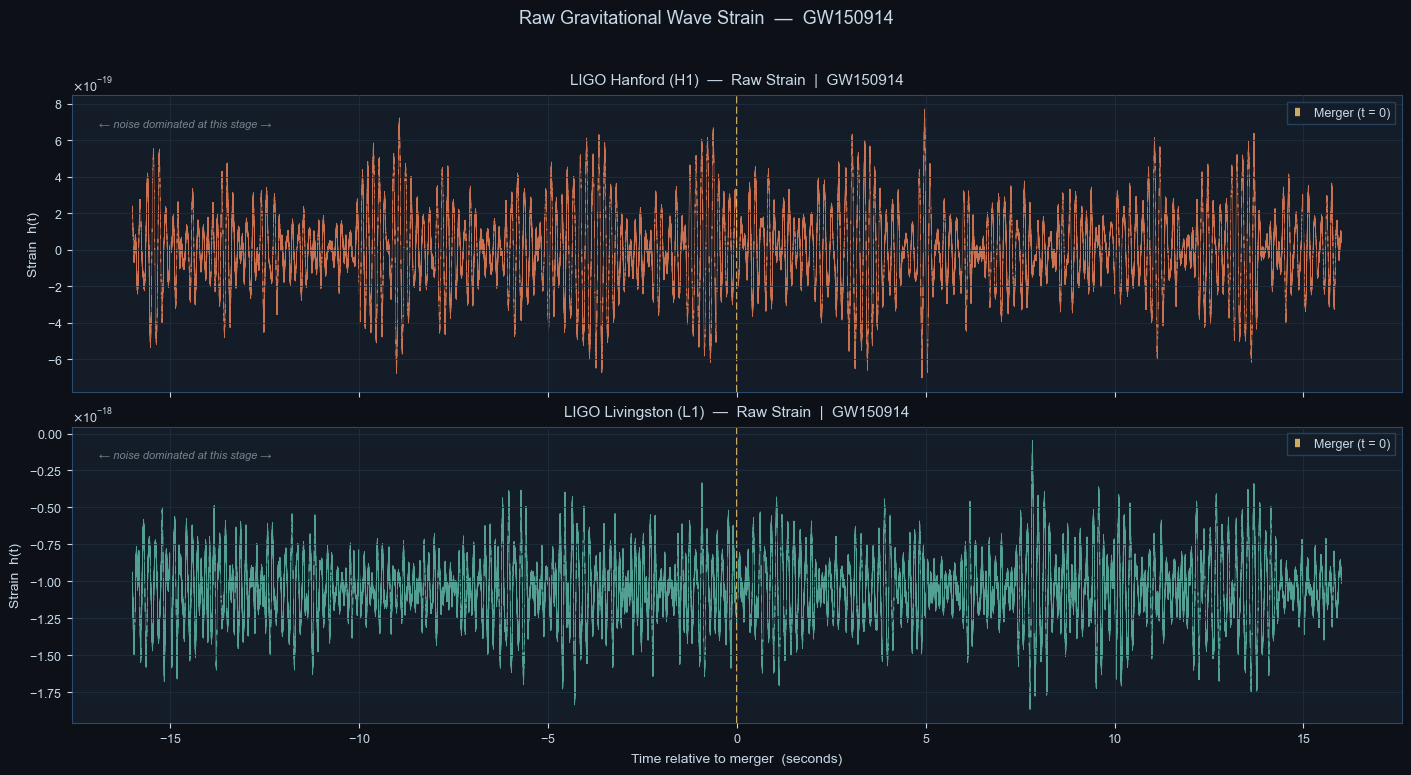

Figure saved → data\raw\GW150914_raw_strain.png


In [7]:
fig, axes = plt.subplots(
    len(DETECTORS), 1,
    figsize=(14, 3.5 * len(DETECTORS)),
    sharex=True
)

if len(DETECTORS) == 1:
    axes = [axes]

DETECTOR_FULL = {
    "H1": "LIGO Hanford (H1)",
    "L1": "LIGO Livingston (L1)",
    "V1": "Virgo (V1)",
}

for ax, det in zip(axes, DETECTORS):
    ts = strain_data[det]
    colour = WA_COLOURS.get(det, "#7eb8e0")

    # GPS-relative time axis (utils.py function)
    t_rel = time_relative_to_merger(ts, GPS_MERGE_TIME)

    ax.plot(t_rel, ts.value, color=colour, lw=0.4, alpha=0.9)

    # Mark the merger
    ax.axvline(0, color=WA_COLOURS["merger"], lw=1.4,
               linestyle="--", alpha=0.85, label="Merger (t = 0)")

    ax.set_ylabel("Strain  h(t)", fontsize=10)
    ax.set_title(
        f"{DETECTOR_FULL.get(det, det)}  —  Raw Strain  |  {EVENT_NAME}",
        fontsize=11, pad=8
    )
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.legend(fontsize=9, loc="upper right")

    # Annotate: point out that this is noise-dominated
    ax.text(
        0.02, 0.92,
        "← noise dominated at this stage →",
        transform=ax.transAxes,
        color=SPACE_TEXT, fontsize=8, alpha=0.55,
        ha="left", va="top", style="italic"
    )

axes[-1].set_xlabel("Time relative to merger  (seconds)", fontsize=10)

fig.suptitle(
    f"Raw Gravitational Wave Strain  —  {EVENT_NAME}",
    fontsize=13, y=1.06, va="bottom"
)

fig_path = RAW_DATA_DIR / f"{EVENT_NAME}_raw_strain.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 6 — Amplitude Spectral Density (ASD)</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A frequency-domain view of the detector noise. This reveals the three noise regimes and shows exactly which frequencies carry the most signal-to-noise ratio.</p>
</div>

### The Amplitude Spectral Density

The **Power Spectral Density** (PSD) S_n(f) describes how noise power is distributed across frequency. If the noise process is stationary, the PSD fully characterises the noise in the frequency domain:

$$\langle \tilde{n}^*(f) \, \tilde{n}(f') \rangle = \frac{1}{2} S_n(f) \, \delta(f - f')$$

The **Amplitude Spectral Density** (ASD) is simply $\sqrt{S_n(f)}$, with units of **strain / √Hz**. The ASD is preferred in LIGO publications because it has the same units as strain, making it straightforward to compare the noise floor to the amplitude of a potential signal.

We estimate the ASD using **Welch's method**: the data is split into overlapping segments, each Fourier-transformed and squared, and the results are averaged. The `method="median"` option uses the median rather than the mean across segments, making the estimate robust to non-stationary noise bursts (glitches) that would otherwise bias the mean upward.

The plot below shows the characteristic LIGO noise curve — sometimes called the **sensitivity curve** or **noise budget**. The bandpass window (35–350 Hz) used in notebook 02 is shaded: this is where GW150914 has signal power and where the noise is manageable.

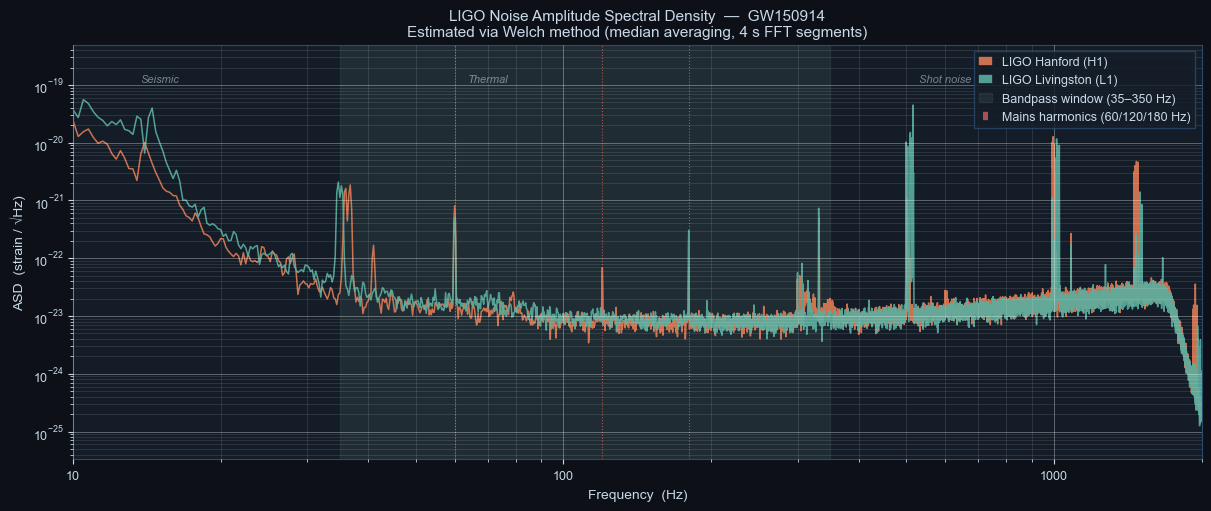

Figure saved → data\raw\GW150914_asd.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

for det, ts in strain_data.items():
    colour = WA_COLOURS.get(det, "#7eb8e0")
    full   = DETECTOR_FULL.get(det, det)

    # Welch PSD → ASD
    # fftlength=4 s gives frequency resolution of 0.25 Hz — fine enough for
    # the mains spectral lines at 60/120/180 Hz to be clearly visible.
    asd = ts.asd(fftlength=SIGNAL.WHITEN_FFTLENGTH, method="median")
    ax.plot(
        asd.frequencies.value, asd.value,
        color=colour, lw=1.1, alpha=0.9, label=full
    )

# Shade the bandpass window used in notebook 02
ax.axvspan(
    SIGNAL.BANDPASS_LOW_HZ, SIGNAL.BANDPASS_HIGH_HZ,
    alpha=0.10, color=WA_COLOURS["bandpass"],
    label=f"Bandpass window ({SIGNAL.BANDPASS_LOW_HZ:.0f}–{SIGNAL.BANDPASS_HIGH_HZ:.0f} Hz)"
)

# Mark the mains-power notch frequencies
for f_notch in SIGNAL.NOTCH_FREQS_HZ:
    ax.axvline(
        f_notch, color="#ff6b6b", lw=0.8, linestyle=":", alpha=0.65,
        label=(f"Mains harmonics (60/120/180 Hz)" if f_notch == 60 else "_nolegend_")
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 2000)
ax.set_xlabel("Frequency  (Hz)", fontsize=10)
ax.set_ylabel("ASD  (strain / √Hz)", fontsize=10)
ax.set_title(
    f"LIGO Noise Amplitude Spectral Density  —  {EVENT_NAME}\n"
    "Estimated via Welch method (median averaging, 4 s FFT segments)",
    fontsize=11
)
ax.legend(fontsize=9)

# Major gridlines
ax.grid(True, which="major", color="white", alpha=0.32, linewidth=0.7)

# Minor gridlines
ax.grid(True, which="minor", color="white", alpha=0.15, linewidth=0.5)



# Label the three noise regimes
ymax = ax.get_ylim()[1]
label_y = ymax * 0.25
for x, label in [(15, "Seismic"), (70, "Thermal"), (600, "Shot noise")]:
    ax.text(
        x, label_y, label,
        color=SPACE_TEXT, fontsize=8, alpha=0.55,
        ha="center", va="center", style="italic"
    )

asd_path = RAW_DATA_DIR / f"{EVENT_NAME}_asd.png"
fig.savefig(asd_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {asd_path}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 7 — Save to HDF5</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Save the raw strain arrays and metadata to disk in HDF5 format. Follow-on notebooks load from this file rather than re-fetching from GWOSC.</p>
</div>

### Why HDF5?

**HDF5 (Hierarchical Data Format 5)** is the de facto standard for large scientific numerical datasets — it is the native storage format used by LIGO internally. Key properties that make it appropriate here:

- **Hierarchical**: datasets are organised in named groups, much like a filesystem. Our structure uses `/H1/strain`, `/H1/times`, `/L1/strain`, `/L1/times`, and `/metadata/`.
- **Self-describing**: each dataset and group can carry metadata attributes (sample rate, event name, GPS bounds) stored alongside the data.
- **Compressed**: we use gzip compression to reduce file size by ~50% with no loss of precision.
- **Fast random access**: large arrays can be read in slices without loading the whole file.

The `h5py` library provides a Python interface that mirrors the file structure as nested dictionaries.

**File structure:**
```
GW150914_raw.hdf5
├── metadata/          attrs: event_name, gps_merge_time, gps_start, gps_end,
│                             detectors, created, source
├── H1/                attrs: sample_rate, n_samples, duration_s
│   ├── strain         float64[131072]  — raw h(t) values
│   └── times          float64[131072]  — GPS timestamps
└── L1/
    ├── strain
    └── times
```

In [9]:
output_path = PATHS.raw_hdf5(EVENT_NAME)

with h5py.File(output_path, "w") as f:

    # ── Metadata group ────────────────────────────────────────────────────────
    meta = f.create_group("metadata")
    meta.attrs["event_name"]      = EVENT_NAME
    meta.attrs["gps_merge_time"]  = GPS_MERGE_TIME
    meta.attrs["gps_start"]       = GPS_START
    meta.attrs["gps_end"]         = GPS_END
    meta.attrs["detectors"]       = DETECTORS
    meta.attrs["created"]         = datetime.now(timezone.utc).isoformat()
    meta.attrs["source"]          = "GWOSC via gwpy.TimeSeries.fetch_open_data"
    meta.attrs["event_type"]      = ev["type"]
    meta.attrs["component_masses"]= ev["masses"]
    meta.attrs["distance_Mpc"]    = ev["distance_Mpc"]

    # ── Per-detector groups ───────────────────────────────────────────────────
    for det, ts in strain_data.items():
        grp = f.create_group(det)

        ds_strain = grp.create_dataset("strain", data=ts.value, compression="gzip")
        ds_strain.attrs["unit"]        = "dimensionless"
        ds_strain.attrs["description"] = "Raw gravitational wave strain h(t)"

        ds_times = grp.create_dataset("times", data=ts.times.value, compression="gzip")
        ds_times.attrs["unit"]        = "GPS seconds"
        ds_times.attrs["description"] = "GPS timestamps corresponding to each strain sample"

        grp.attrs["sample_rate"] = float(ts.sample_rate.value)
        grp.attrs["n_samples"]   = len(ts)
        grp.attrs["duration_s"]  = float(ts.duration.value)

        print(f"  Saved {det}: {len(ts):,} samples @ {ts.sample_rate}")

size_kb = output_path.stat().st_size / 1024
print(f"\n✓ HDF5 written → {output_path}")
print(f"  File size: {size_kb:.1f} KB")

  Saved H1: 131,072 samples @ 4096.0 Hz
  Saved L1: 131,072 samples @ 4096.0 Hz

✓ HDF5 written → data\raw\GW150914_raw.hdf5
  File size: 2305.9 KB


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 8 — Verify the Saved File</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Read the file back independently to confirm it was written correctly. This also demonstrates how downstream notebooks will load the data.</p>
</div>

In [10]:
# Use the utils helper to print a readable file tree
print_hdf5_tree(output_path)

print()
# Spot-check data integrity by loading back and comparing shapes
print("Spot-check — shapes and sample rates:")
with h5py.File(output_path, "r") as f:
    for det in DETECTORS:
        s_shape = f[det]["strain"].shape
        t_shape = f[det]["times"].shape
        fs      = f[det].attrs["sample_rate"]
        print(f"  {det}  strain:{s_shape}  times:{t_shape}  @{fs:.0f} Hz")

print("\n✓ Verification passed — file is readable and complete.")


data\raw\GW150914_raw.hdf5
📁 H1/
  📊 strain: shape=(131072,), dtype=float64
  📊 times: shape=(131072,), dtype=float64
📁 L1/
  📊 strain: shape=(131072,), dtype=float64
  📊 times: shape=(131072,), dtype=float64
📁 metadata/

  Metadata attributes:
    component_masses: 36 + 29 M☉
    created: 2026-06-26T13:25:45.775657+00:00
    detectors: ['H1' 'L1']
    distance_Mpc: 410
    event_name: GW150914
    event_type: BBH
    gps_end: 1126259478
    gps_merge_time: 1126259462
    gps_start: 1126259446
    source: GWOSC via gwpy.TimeSeries.fetch_open_data

Spot-check — shapes and sample rates:
  H1  strain:(131072,)  times:(131072,)  @4096 Hz
  L1  strain:(131072,)  times:(131072,)  @4096 Hz

✓ Verification passed — file is readable and complete.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 9 — Save Event Catalogue</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Save the full event catalogue as JSON. Later notebooks can reference this file when building multi-event datasets or classification tasks.</p>
</div>

In [11]:
catalogue_path = RAW_DATA_DIR / "event_catalogue.json"

with open(catalogue_path, "w") as fp:
    json.dump(EVENT_CATALOGUE, fp, indent=2)

print("Event catalogue:")
print(f"  {'Event':<12} {'Type':<5} {'GPS Time':<12} {'Masses':<20} {'Dist (Mpc)':<12} Note")
print("  " + "-" * 90)
for name, info in EVENT_CATALOGUE.items():
    marker = " ← active" if name == EVENT_NAME else ""
    print(
        f"  {name:<12} {info['type']:<5} {info['gps']:<12} "
        f"{info['masses']:<20} {info['distance_Mpc']:<12} {info['note'][:45]}{marker}"
    )

print(f"\nCatalogue saved → {catalogue_path}")

Event catalogue:
  Event        Type  GPS Time     Masses               Dist (Mpc)   Note
  ------------------------------------------------------------------------------------------
  GW150914     BBH   1126259462   36 + 29 M☉           410          First ever direct detection. Two stellar-mass ← active
  GW170814     BBH   1186741861   30.5 + 25.3 M☉       540          First triple-detector observation; allowed sk
  GW170817     BNS   1187008882   1.36 + 1.17 M☉       40           Binary neutron star — with optical/radio/X-ra
  GW190521     BBH   1242442967   95 + 69 M☉           5300         Heaviest BBH detected at the time; remnant ex
  GW200105     NSBH  1262276512   8.9 + 1.9 M☉         280          Neutron star–black hole merger; the lighter c

Catalogue saved → data\raw\event_catalogue.json


<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 100%); padding: 28px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-top: 16px;">

<h2 style="color: #e8f4fd; font-weight: 300; margin: 0 0 18px 0; font-size: 1.4em;">Summary & Next Steps</h2>

<p style="color: #a0c4de; margin: 0 0 16px 0;"><strong style="color: #e8f4fd;">What this notebook did:</strong></p>

<ul style="color: #c8dce8; margin: 0 0 20px 0; padding-left: 20px; line-height: 1.8;">
<li>Connected to <a href="https://gwosc.org/" target="_blank">GWOSC</a> and fetched real strain data for <strong style="color: #e8f4fd;">GW150914</strong> from two detectors</li>
<li>Applied a colour theme to enahce the look of the workbook</li>
<li>Inspected the <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">TimeSeries</code> object structure and metadata</li>
<li>Plotted raw strain (which was noise-dominated and expected at this stage)</li>
<li>Plotted the <strong style="color: #e8f4fd;">Amplitude Spectral Density</strong> revealing seismic, thermal, and shot noise regimes</li>
<li>Saved data to structured HDF5 with full provenance metadata</li>
<li>Built a catalogue of 5 landmark events for future batch acquisition to allow easy retreaval and analysis of these in future</li>
<li>More importantly this catalogue sets the framework for how additional events could be added</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 10px 0;"><strong style="color: #e8f4fd;">Outputs written:</strong></p>
<pre style="background: rgba(78,158,202,0.08); border: 1px solid rgba(78,158,202,0.2); border-radius: 6px; padding: 12px 16px; color: #7eb8e0; font-size: 0.9em; margin: 0 0 20px 0;">
data/raw/
├── GW150914_raw.hdf5          ← strain + timestamps for H1 and L1
├── GW150914_raw_strain.png    ← raw time-domain signal plot
├── GW150914_asd.png           ← noise ASD plot
└── event_catalogue.json       ← reference catalogue for future notebooks
</pre>

<p style="color: #a0c4de; margin: 0 0 6px 0;"><strong style="color: #e8f4fd;">Next — <code style="background: rgba(78,158,202,0.15); padding: 2px 6px; border-radius: 3px; color: #7eb8e0;">02_preprocessing.ipynb</code>:</strong></p>
<p style="color: #c8dce8; margin: 0;">Load the HDF5 file, compute the ASD, and apply <strong>whitening</strong> to flatten the noise spectrum to unit variance across all frequencies. Then apply a <strong>bandpass filter</strong> (35–350 Hz) to isolate the signal band, and <strong>notch filters</strong> at 60/120/180 Hz to remove US mains power interference. After these steps, the gravitational wave chirp of GW150914 will become visible for the first time.</p>

</div>